<a href="https://colab.research.google.com/github/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP/blob/luke/LGBM_x_LSTM_x_BHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [44]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
QUANTILES = [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975]
SEQ_LENGTH = 28
PRED_LENGTH = 28
NUM_ITEMS = 200        # Small subset for rapid prototyping, scale up for production
BATCH_SIZE = 1024
EPOCHS = 5

# Data Download and trim

In [45]:
def download_m5_data():
    print("Downloading dataset from Hugging Face...")
    df = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv")
    calendar = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/calendar.csv")
    prices = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/sell_prices.csv")
    print(f"✅ Download complete. Sales shape: {df.shape}")
    return df, calendar, prices

def trim_data(df: pd.DataFrame, num_items: int) -> pd.DataFrame:
    print(f"Selecting the TOP {num_items} highest-volume items...")
    day_cols = [c for c in df.columns if c.startswith('d_')]
    df['total_sales_volume'] = df[day_cols].sum(axis=1)
    trimmed_df = df.sort_values('total_sales_volume', ascending=False).head(num_items).copy()
    trimmed_df = trimmed_df.drop(columns=['total_sales_volume'])
    return trimmed_df

sales, calendar, prices = download_m5_data()
sales_trimmed = trim_data(sales, NUM_ITEMS)

✅ Download complete. Sales shape: (30490, 1947)
Selecting the TOP 200 highest-volume items...


# Data Preprocessing for LSTM (Tensors)

In [46]:
# --- REPLACEMENT FOR CELL 3 ---
def preprocess_lstm_data_with_revenue_weights(df: pd.DataFrame, prices_df: pd.DataFrame):
    print("Building windows and calculating REVENUE-based item weights...")

    # 1. Fast Price Merge: Calculate average price per item/store to avoid RAM explosion
    avg_prices = prices_df.groupby(['item_id', 'store_id'])['sell_price'].mean().reset_index()
    df = df.merge(avg_prices, on=['item_id', 'store_id'], how='left')

    # Fill any missing prices with the dataset median just in case
    global_median_price = prices_df['sell_price'].median()
    df['sell_price'] = df['sell_price'].fillna(global_median_price)

    # Encode categorical hierarchy
    for col in ['state_id', 'store_id', 'cat_id', 'dept_id']:
        df[f'{col}_int'] = df[col].astype('category').cat.codes

    day_cols = [c for c in df.columns if c.startswith('d_')]
    data_array = df[day_cols].values.astype(np.float32)
    num_items, total_days = data_array.shape

    day_of_week = (np.arange(total_days) + 5) % 7
    test_days = 28
    train_array = data_array[:, :-test_days]

    # 2. Calculate Revenue Weights (Volume * Price)
    item_volumes = train_array.sum(axis=1)
    item_revenues = item_volumes * df['sell_price'].values
    item_weights = item_revenues / item_revenues.sum() # Normalize so weights sum to 1.0

    X_train_list, y_train_list, w_train_list = [], [], []
    X_test_list, y_test_list, w_test_list = [], [], []

    for item_idx in range(num_items):
        static_feats = [df.iloc[item_idx][f'{c}_int'] for c in ['state_id', 'store_id', 'cat_id', 'dept_id']]
        i_weight = item_weights[item_idx]

        # Train
        for t in range(train_array.shape[1] - SEQ_LENGTH):
            sales_window = train_array[item_idx, t : t + SEQ_LENGTH].reshape(-1, 1)
            dow_window = day_of_week[t : t + SEQ_LENGTH].reshape(-1, 1)
            f_block = np.tile(static_feats, (SEQ_LENGTH, 1))
            X_train_list.append(np.hstack([sales_window, f_block, dow_window]))
            y_train_list.append(train_array[item_idx, t + SEQ_LENGTH])
            w_train_list.append(i_weight)

        # Test
        sales_seed = data_array[item_idx, -(test_days + SEQ_LENGTH) : -test_days].reshape(-1, 1)
        dow_seed = day_of_week[-(test_days + SEQ_LENGTH) : -test_days].reshape(-1, 1)
        f_block_test = np.tile(static_feats, (SEQ_LENGTH, 1))
        X_test_list.append(np.hstack([sales_seed, f_block_test, dow_seed]))
        y_test_list.append(data_array[item_idx, -test_days:])
        w_test_list.append(i_weight)

    return {
        "X_train": torch.tensor(np.array(X_train_list), dtype=torch.float32),
        "y_train": torch.tensor(np.array(y_train_list), dtype=torch.float32),
        "w_train": torch.tensor(np.array(w_train_list), dtype=torch.float32),
        "X_test": torch.tensor(np.array(X_test_list), dtype=torch.float32),
        "y_test": torch.tensor(np.array(y_test_list), dtype=torch.float32),
        "w_test": torch.tensor(np.array(w_test_list), dtype=torch.float32)
    }

# Execute function, passing in BOTH the trimmed sales and the prices dataframe
tensors = preprocess_lstm_data_with_revenue_weights(sales_trimmed, prices)

train_dataset = TensorDataset(tensors["X_train"].to(DEVICE), tensors["y_train"].to(DEVICE), tensors["w_train"].to(DEVICE))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Building windows and calculating REVENUE-based item weights...


# LSTM & BHMLSTM Architecture and Loss

In [47]:
class PinballLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target):
        if target.dim() == 1:
            target = target.unsqueeze(1)
        losses = []
        for i, q in enumerate(self.quantiles):
            errors = target - preds[:, i:i+1]
            loss_q = torch.max((q - 1) * errors, q * errors)
            losses.append(loss_q)
        return torch.stack(losses, dim=-1).mean(dim=0).sum()

class WeightedPinballLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target, weights):
        if target.dim() == 1:
            target = target.unsqueeze(1)
        if weights.dim() == 1:
            weights = weights.unsqueeze(1)

        losses = []
        for i, q in enumerate(self.quantiles):
            errors = target - preds[:, i:i+1]
            # Standard pinball calculation
            loss_q = torch.max((q - 1) * errors, q * errors)
            losses.append(loss_q)

        # Combine quantiles and apply item weights via broadcasting
        stacked_losses = torch.cat(losses, dim=1)
        weighted_losses = stacked_losses * weights

        return weighted_losses.mean(dim=0).sum()

# Baseline LSTM
class QuantileLSTM(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, num_quantiles=7):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_quantiles)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# Advanced BHM LSTM
class BHMLSTM(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128, num_layers=2, num_quantiles=7, dropout_rate=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_quantiles)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out)

## Training

In [48]:
def train_nn_model(model, name):
    print(f"\n🚀 Training {name}...")
    criterion = WeightedPinballLoss(QUANTILES)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        # Now unpacking 3 variables from the dataloader
        for batch_X, batch_y, batch_w in train_loader:
            optimizer.zero_grad(set_to_none=True)
            preds = model(batch_X)
            loss = criterion(preds, batch_y, batch_w) # Pass weights to loss
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        print(f"   Epoch {epoch+1}/{EPOCHS} | Avg Weighted Loss: {avg_loss:.6f} | Time: {time.time()-start_time:.2f}s")
    return model

lstm_model = train_nn_model(QuantileLSTM(input_dim=6).to(DEVICE), "Standard LSTM")
bhm_model = train_nn_model(BHMLSTM(input_dim=6).to(DEVICE), "BHM LSTM")


🚀 Training Standard LSTM...
   Epoch 1/5 | Avg Weighted Loss: 0.414042 | Time: 6.09s
   Epoch 2/5 | Avg Weighted Loss: 0.253771 | Time: 5.45s
   Epoch 3/5 | Avg Weighted Loss: 0.195597 | Time: 5.53s
   Epoch 4/5 | Avg Weighted Loss: 0.164002 | Time: 5.94s
   Epoch 5/5 | Avg Weighted Loss: 0.144217 | Time: 5.31s

🚀 Training BHM LSTM...
   Epoch 1/5 | Avg Weighted Loss: 0.177367 | Time: 12.76s
   Epoch 2/5 | Avg Weighted Loss: 0.089613 | Time: 12.85s
   Epoch 3/5 | Avg Weighted Loss: 0.086074 | Time: 13.20s
   Epoch 4/5 | Avg Weighted Loss: 0.084314 | Time: 12.44s
   Epoch 5/5 | Avg Weighted Loss: 0.083347 | Time: 12.29s


# Baseline LightGBM Training (Simplified Auto-regressive for comparison)

In [49]:
# --- REPLACEMENT FOR CELL 6 ---
print("\n🚀 Training LightGBM Quantile Models...")
X_train_lgb = tensors["X_train"][:, :, 0].numpy()
y_train_lgb = tensors["y_train"].numpy()
w_train_lgb = tensors["w_train"].numpy() # Extract weights

# Pass the weights directly into the LightGBM Dataset
lgb_train = lgb.Dataset(X_train_lgb, y_train_lgb, weight=w_train_lgb)
lgbm_models = {}

target_quantiles = [0.05, 0.5, 0.95]

for q in target_quantiles:
    print(f"   Training LGBM for quantile {q}...")
    params = {
        'objective': 'quantile',
        'alpha': q,
        'metric': 'quantile',
        'learning_rate': 0.05,
        'verbose': -1
    }
    lgbm_models[q] = lgb.train(params, lgb_train, num_boost_round=100)

print("   LightGBM Training Complete.")


🚀 Training LightGBM Quantile Models...
   Training LGBM for quantile 0.05...
   Training LGBM for quantile 0.5...
   Training LGBM for quantile 0.95...
   LightGBM Training Complete.


# Unified Recursive Forecasting & Visualization (The Comparison)

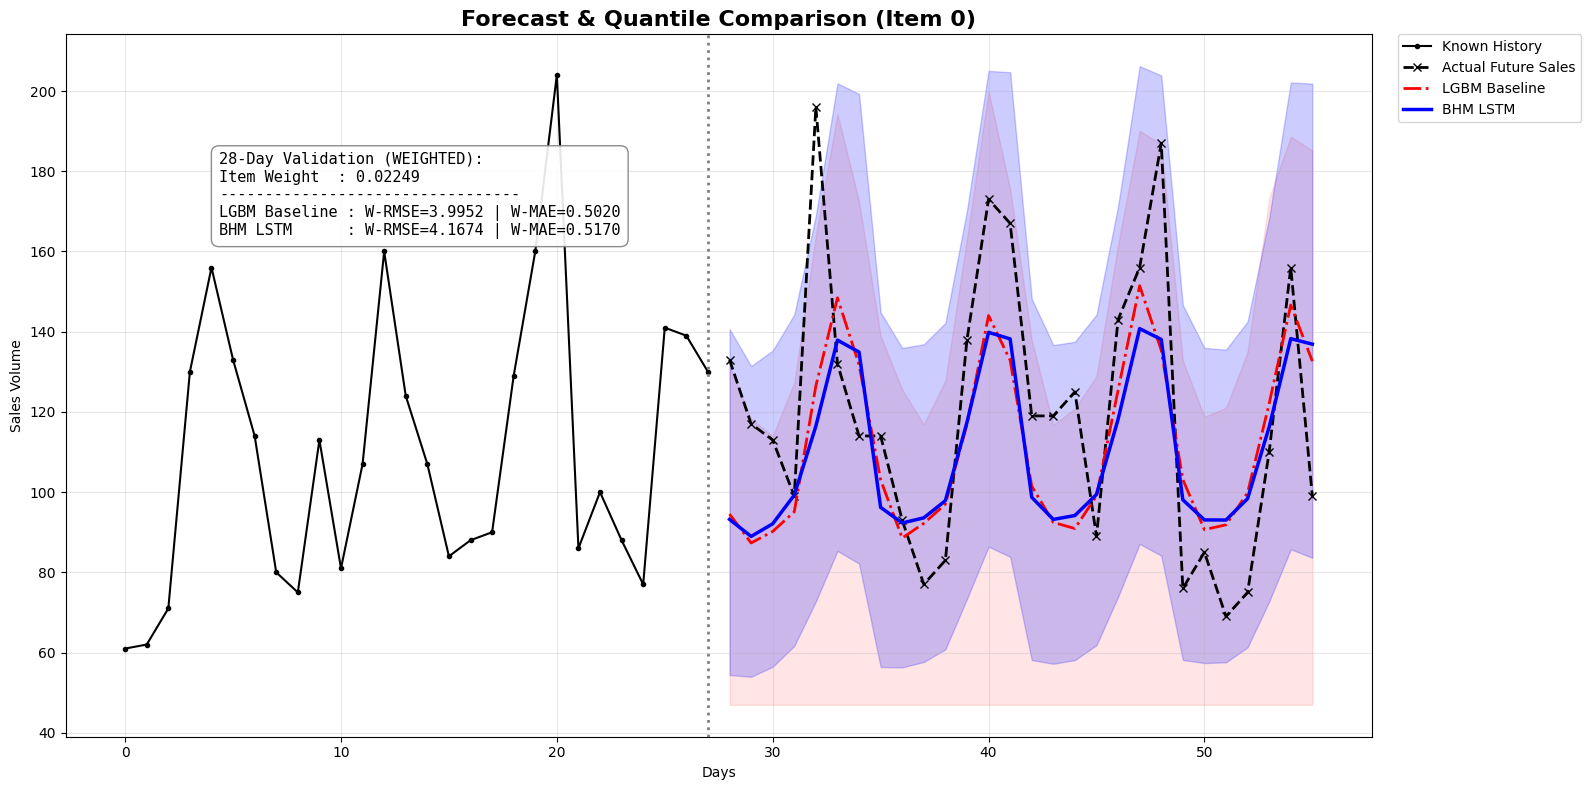

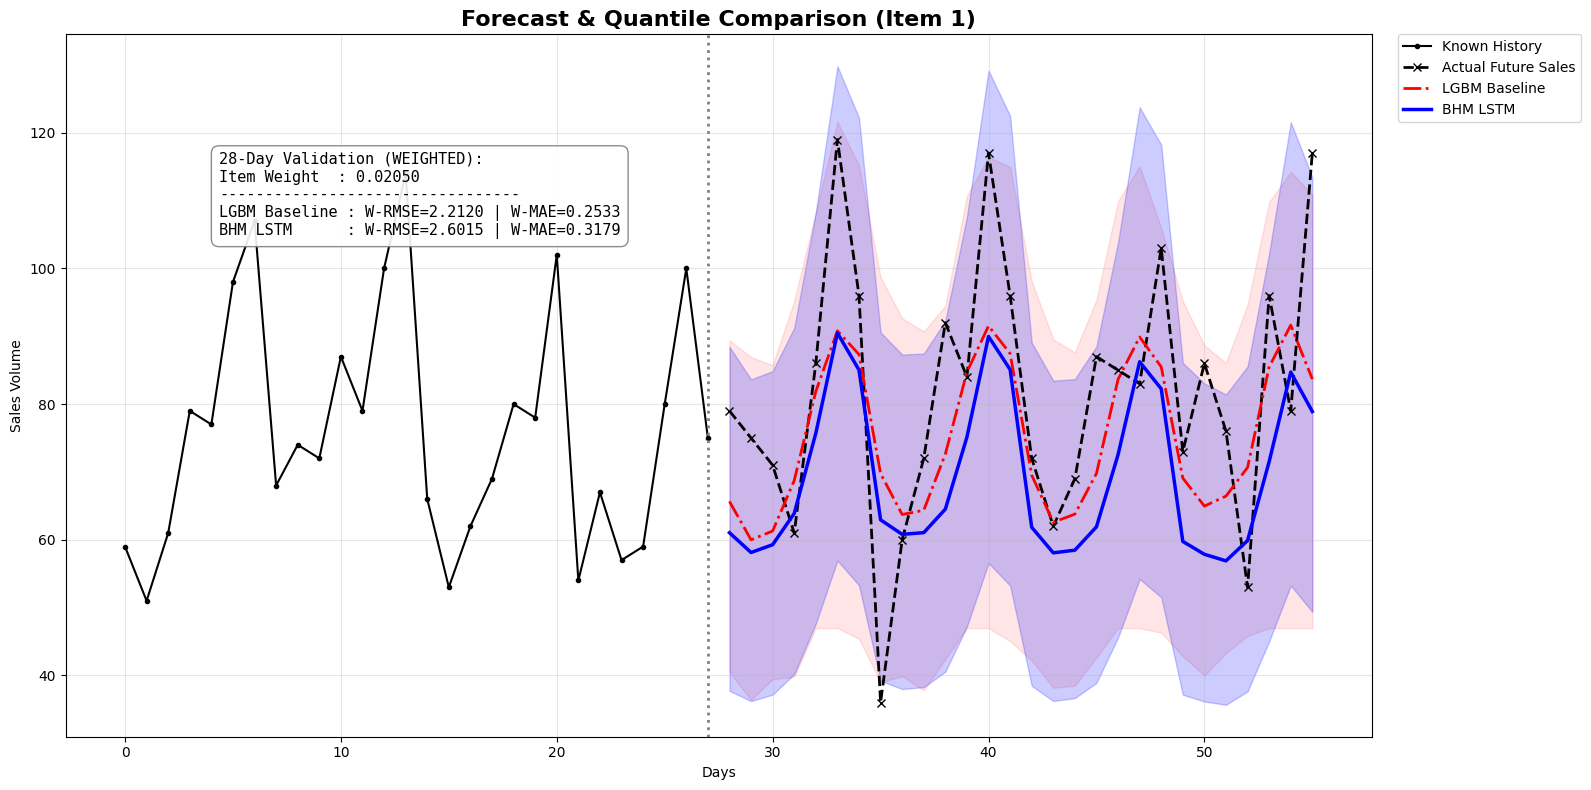

In [50]:
def predict_28_days_nn_quantiles(model, initial_history, device):
    model.eval()
    current_window = initial_history.copy()
    predictions = [] # Will store all 7 quantiles
    idx_median = QUANTILES.index(0.5)
    static_ids = current_window[0, 1:5]

    for step in range(28):
        x_tensor = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_quantiles = model(x_tensor).cpu().numpy()[0]

        # Prevent negative predictions across all quantiles
        pred_quantiles = np.maximum(0.0, pred_quantiles)
        predictions.append(pred_quantiles)

        # We must use the median (50th percentile) to feed back into the autoregressive loop
        median_pred = pred_quantiles[idx_median]

        # Increment Day of Week
        last_dow = current_window[-1, 5]
        new_dow = (last_dow + 1) % 7

        new_row = np.concatenate([[median_pred], static_ids, [new_dow]])
        current_window = np.vstack([current_window[1:], new_row])

    return np.array(predictions) # Returns shape (28, 7)
def predict_28_days_lgb_quantiles(models_dict, initial_history):
    current_window = initial_history[:, 0].copy()
    predictions = {q: [] for q in models_dict.keys()}

    for step in range(28):
        features = current_window[-28:].reshape(1, -28)

        step_preds = {}
        for q, model in models_dict.items():
            pred = model.predict(features)[0]
            step_preds[q] = max(0.0, pred)
            predictions[q].append(step_preds[q])

        # We must use the median (0.5) to feed back into the autoregressive loop
        current_window = np.append(current_window, step_preds[0.5])

    return predictions

def compare_models_plot_with_quantiles(item_idx=0):
    seed_full = tensors["X_test"][item_idx].numpy()
    actual = tensors["y_test"][item_idx].numpy()
    item_weight = tensors["w_test"][item_idx].numpy().item() # Get this item's weight
    historical = seed_full[:, 0]

    lstm_preds_q = predict_28_days_nn_quantiles(lstm_model, seed_full, DEVICE)
    bhm_preds_q = predict_28_days_nn_quantiles(bhm_model, seed_full, DEVICE)
    lgbm_preds_dict = predict_28_days_lgb_quantiles(lgbm_models, seed_full)

    idx_median = QUANTILES.index(0.5)
    lstm_median = lstm_preds_q[:, idx_median]
    bhm_median = bhm_preds_q[:, idx_median]
    lgbm_median = np.array(lgbm_preds_dict[0.5])

    # NEW: Calculate Weighted Metrics
    def get_weighted_metrics(pred, true, w):
        w_rmse = np.sqrt(np.mean(w * (true - pred)**2))
        w_mae = np.mean(w * np.abs(true - pred))
        return w_rmse, w_mae

    lgbm_wrmse, lgbm_wmae = get_weighted_metrics(lgbm_median, actual, item_weight)
    lstm_wrmse, lstm_wmae = get_weighted_metrics(lstm_median, actual, item_weight)
    bhm_wrmse, bhm_wmae = get_weighted_metrics(bhm_median, actual, item_weight)

    time_hist = np.arange(len(historical))
    time_pred = np.arange(len(historical), len(historical) + 28)

    plt.figure(figsize=(16, 8))

    plt.plot(time_hist, historical, label="Known History", color="black", marker='.')
    plt.plot(time_pred, actual, label="Actual Future Sales", color="black", linestyle="--", marker='x', linewidth=2)

    plt.plot(time_pred, lgbm_median, label="LGBM Baseline", color="red", linestyle="-.", linewidth=2)
    plt.fill_between(time_pred, lgbm_preds_dict[0.05], lgbm_preds_dict[0.95], color="red", alpha=0.1)

    # plt.plot(time_pred, lstm_median, label="Standard LSTM", color="orange", linewidth=2)
    # plt.fill_between(time_pred, lstm_preds_q[:, 1], lstm_preds_q[:, 5], color="orange", alpha=0.15)

    plt.plot(time_pred, bhm_median, label="BHM LSTM", color="blue", linewidth=2.5)
    plt.fill_between(time_pred, bhm_preds_q[:, 1], bhm_preds_q[:, 5], color="blue", alpha=0.2)

    # Display Weighted Metrics
    metrics_text = (
        f"28-Day Validation (WEIGHTED):\n"
        f"Item Weight  : {item_weight:.5f}\n"
        f"---------------------------------\n"
        f"LGBM Baseline : W-RMSE={lgbm_wrmse:.4f} | W-MAE={lgbm_wmae:.4f}\n"
        #f"Standard LSTM : W-RMSE={lstm_wrmse:.4f} | W-MAE={lstm_wmae:.4f}\n"
        f"BHM LSTM      : W-RMSE={bhm_wrmse:.4f} | W-MAE={bhm_wmae:.4f}"
    )
    plt.gcf().text(0.14, 0.70, metrics_text, fontsize=11, family='monospace',
                   bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

    plt.axvline(x=len(historical) - 1, color='gray', linestyle=':', linewidth=2)
    plt.title(f"Forecast & Quantile Comparison (Item {item_idx})", fontsize=16, fontweight='bold')
    plt.xlabel("Days")
    plt.ylabel("Sales Volume")

    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

compare_models_plot_with_quantiles(item_idx=0)
compare_models_plot_with_quantiles(item_idx=1)